In [1]:
# imports
from numpy import asarray, arange
from numpy.random import rand, seed
from numpy import arange
from numpy import meshgrid
import numpy as np
from matplotlib import pyplot 

In [12]:
def objective(x,y):
    return x**2.0 + y**2.0

# derivative funtion 
def derivative(x,y):
    return asarray([x*2.0, y*2.0])

In [8]:
# grad descent
from math import sqrt

def adagrad(objective, derivative, bounds, n_iter, step_size):

    # generate initial point
    solution = bounds[:, 0] + rand(len(bounds)) * (bounds[:, 1] - bounds[:, 0])

    # list of the sum square gradients for each variable
    sq_grad_sums = [0.0 for _ in range(bounds.shape[0])]

    # run the gradient descent
    for it in range(n_iter):

        # calculate gradient
        gradient = derivative(solution[0], solution[1])

        # update squared gradient accumulators
        for i in range(len(gradient)):
            sq_grad_sums[i] += gradient[i] ** 2.0

        # build new solution
        new_solution = []
        for i in range(len(solution)):
            # Adagrad step size
            alpha = step_size / (1e-8 + sqrt(sq_grad_sums[i]))

            # update variable
            value = solution[i] - alpha * gradient[i]
            new_solution.append(value)

        # update solution vector
        solution = asarray(new_solution)

        # evaluate candidate point
        solution_eval = objective(solution[0], solution[1])

        # print progress
        print(f'{it+1}, {solution} : {solution_eval}')

    return solution, solution_eval


# ----------------------------------------
# RUNNING IT
# ----------------------------------------
seed(42)
bounds = asarray([[-1.0, 1.0], [-1.0, 1.0]])
n_iter = 40
step_size = 0.1

best, score = adagrad(objective, derivative, bounds, n_iter, step_size)
print(f'\nBest solution: {best} : {score}')

1, [-0.15091976  0.80142861] : (0.6650645975911327, 0)
2, [-0.09937783  0.73498488] : (0.5500787251339498, 0)
3, [-0.06723901  0.68294935] : (0.4709408984010412, 0)
4, [-0.04599045  0.63941922] : (0.4109720573011417, 0)
5, [-0.03160788  0.60167774] : (0.3630151554495336, 0)
6, [-0.0217711  0.5682117] : (0.32333851567232347, 0)
7, [-0.01501115  0.53807631] : (0.28975144746761644, 0)
8, [-0.01035523  0.51063467] : (0.26085500184444865, 0)
9, [-0.00714506  0.48543311] : (0.2356963557149695, 0)
10, [-0.0049306   0.46213464] : (0.21359273292564998, 0)
11, [-0.00340265  0.44048063] : (0.1940347662464659, 0)
12, [-0.00234825  0.4202673 ] : (0.17663011628139522, 0)
13, [-0.00162061  0.40133049] : (0.16106878992495777, 0)
14, [-0.00111844  0.38353558] : (0.14710078957379974, 0)
15, [-0.00077188  0.36677038] : (0.13452110897521008, 0)
16, [-0.0005327   0.35094019] : (0.12315929885156984, 0)
17, [-0.00036764  0.33596406] : (0.11287198794534556, 0)
18, [-2.53723807e-04  3.21772153e-01] : (0.103537

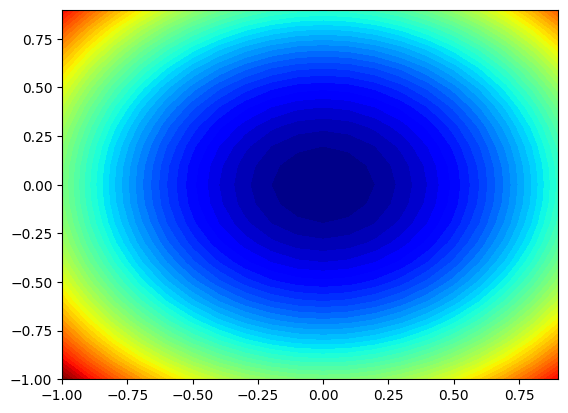

In [13]:
bounds = asarray([[-1.0, 1.0], [-1.0, 1.0]])

xaxis = arange(bounds[0,0], bounds[0,1], 0.1)
yaxis = arange(bounds[1,0], bounds[1,1], 0.1)

x, y = meshgrid(xaxis, yaxis)
results = objective(x, y)

pyplot.contourf(x, y, results, levels=50, cmap='jet')
pyplot.show()
